# CloudWalk AML-FT — Exploração de Dados
**Banco SQLite local:** `aml.db`  
**Tabelas:** `transactions`, `kyc_profiles`, `merchants`, `geo_behavior`, `data_dictionary`  
**Dataset:** 52.000 transações · 2.500 clientes · 1.000 merchants · Jul–Out 2025

---
**Estrutura do notebook:**
1. Setup + Visão Geral
2. Tipologias AML (queries exploratórias)
3. Score de Risco Ponderado (Tarefa 1)
4. Sistema de Alertas — resultados (Tarefa 2)
5. ML Risk Scoring — resultados (Tarefa 3)
6. Multi-agente LLM — outputs (Tarefa 4)

In [1]:
import sqlite3
import pandas as pd
import json
import os
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 60)
pd.set_option('display.float_format', '{:.2f}'.format)

BASE = '/Users/limaslucas197/Documents/cw-risk-aml-test/'
DB   = BASE + 'aml.db'

if not os.path.exists(DB):
    raise FileNotFoundError(f'Banco não encontrado: {DB}')

def q(sql):
    """Roda query SQL e retorna DataFrame."""
    with sqlite3.connect(DB) as conn:
        return pd.read_sql(sql, conn)

tables = [r[0] for r in sqlite3.connect(DB).execute("SELECT name FROM sqlite_master WHERE type='table'").fetchall()]
print('Conectado:', DB)
print('Tabelas:', tables)

Conectado: /Users/limaslucas197/Documents/cw-risk-aml-test/aml.db
Tabelas: ['transactions', 'kyc_profiles', 'merchants', 'geo_behavior', 'data_dictionary']


## 1. Visão Geral

In [2]:
# Contagem por tabela
for t in ['transactions', 'kyc_profiles', 'merchants', 'geo_behavior']:
    n = q(f'SELECT COUNT(*) as n FROM {t}').iloc[0,0]
    print(f'{t:20s}: {n:,} linhas')

transactions        : 52,000 linhas
kyc_profiles        : 2,500 linhas
merchants           : 1,000 linhas
geo_behavior        : 3,497 linhas


In [3]:
# Distribuição por rail
q("""
SELECT transaction_type, COUNT(*) n,
       ROUND(COUNT(*)*100.0/52000,1) pct,
       ROUND(SUM(CAST(amount_brl AS REAL)),2) volume_brl
FROM transactions
GROUP BY transaction_type ORDER BY n DESC
""")

,transaction_type,n,pct,volume_brl
0,PIX,31547,60.70,140147951.23
1,Card,17930,34.50,79398049.89
2,Wire,2523,4.90,10511856.46


In [4]:
# Sinais de risco — overview
q("""
SELECT
  SUM(CASE WHEN sanctions_screening_hit='Yes' THEN 1 ELSE 0 END) sanctions_hit,
  SUM(CASE WHEN ip_proxy_vpn_tor != 'None' THEN 1 ELSE 0 END)   vpn_proxy_tor,
  SUM(CASE WHEN cross_border='Yes' THEN 1 ELSE 0 END)           cross_border,
  SUM(CASE WHEN country_risk_geo='High' THEN 1 ELSE 0 END)      high_risk_geo,
  SUM(CASE WHEN device_rooted='Yes' THEN 1 ELSE 0 END)          device_rooted
FROM transactions
""")

,sanctions_hit,vpn_proxy_tor,cross_border,high_risk_geo,device_rooted
0,2,3663,10113,590,1562


In [5]:
# KYC — PEP / sancionados / alto risco
q("""
SELECT
  SUM(CASE WHEN pep='Yes' THEN 1 ELSE 0 END)               pep,
  SUM(CASE WHEN sanctions_list_hit='Yes' THEN 1 ELSE 0 END) sanctioned,
  SUM(CASE WHEN risk_rating='High' THEN 1 ELSE 0 END)       high_risk,
  SUM(CASE WHEN beneficial_owner='Yes' THEN 1 ELSE 0 END)   beneficial_owner,
  COUNT(*) total
FROM kyc_profiles
""")

,pep,sanctioned,high_risk,beneficial_owner,total
0,80,9,196,207,2500


## 2. Tipologias AML

### 2.1 Structuring / Smurfing
Fragmentação deliberada de valores abaixo de R$10.000 para evitar reporte automático ao COAF.
A zona suspeita clássica é R$9.000–R$9.999: alto o suficiente para mover volume, baixo o suficiente para evitar flag.

In [6]:
# Structuring clássico — ≥3 txs na faixa R$9k–R$9.999
q("""
SELECT sender_id, COUNT(*) n_txs,
       ROUND(SUM(CAST(amount_brl AS REAL)),2) total_brl,
       MIN(timestamp) primeira, MAX(timestamp) ultima
FROM transactions
WHERE CAST(amount_brl AS REAL) BETWEEN 9000 AND 9999.99
GROUP BY sender_id HAVING n_txs >= 3
ORDER BY n_txs DESC, total_brl DESC
""")

,sender_id,n_txs,total_brl,primeira,ultima
0,C101854,4,38070.72,2025-07-10T15:47:41,2025-10-02T23:47:06
1,C102228,3,29177.06,2025-08-06T00:37:55,2025-09-21T18:07:37
2,C100866,3,29135.09,2025-07-27T05:22:24,2025-10-02T03:15:43
3,C101141,3,28788.66,2025-08-20T05:52:00,2025-08-28T00:16:19
4,C100300,3,28601.07,2025-07-10T14:54:55,2025-08-10T10:37:14
5,C100351,3,28598.22,2025-08-09T01:05:56,2025-09-22T05:39:11
6,C101662,3,28474.35,2025-07-21T20:41:02,2025-10-04T10:59:32
7,C101563,3,28359.64,2025-07-05T18:25:46,2025-09-06T14:01:36
8,C101218,3,28252.63,2025-08-18T21:05:20,2025-09-24T23:21:40
9,C101534,3,28243.20,2025-07-21T17:43:18,2025-09-13T11:59:19


In [7]:
# Structuring por velocidade — ≥4 txs sub-R$10k em 24h (top 20)
q("""
SELECT sender_id,
       DATE(timestamp) dia,
       COUNT(*) n_txs,
       ROUND(SUM(CAST(amount_brl AS REAL)),2) total_brl,
       ROUND(MAX(CAST(amount_brl AS REAL)),2) maior_tx,
       ROUND(MIN(CAST(amount_brl AS REAL)),2) menor_tx,
       ROUND(AVG(CAST(amount_brl AS REAL)),2) media_tx,
       MIN(timestamp) primeira,
       MAX(timestamp) ultima,
       ROUND((JULIANDAY(MAX(timestamp))-JULIANDAY(MIN(timestamp)))*60,0) minutos_span
FROM transactions
WHERE CAST(amount_brl AS REAL) < 10000
GROUP BY sender_id, DATE(timestamp)
HAVING n_txs >= 4
ORDER BY n_txs DESC, total_brl DESC
LIMIT 20
""")

,sender_id,dia,n_txs,total_brl,maior_tx,menor_tx,media_tx,primeira,ultima,minutos_span
0,C102023,2025-09-07,4,19954.17,7282.43,2943.11,4988.54,2025-09-07T01:26:59,2025-09-07T10:39:40,23.00
1,C101205,2025-07-08,4,16212.56,6391.46,1353.43,4053.14,2025-07-08T00:45:19,2025-07-08T22:06:51,53.00
2,C100442,2025-08-09,4,11861.60,6145.69,1654.40,2965.40,2025-08-09T02:42:49,2025-08-09T19:19:47,42.00
3,C100582,2025-09-12,4,8391.82,3432.79,1297.14,2097.95,2025-09-12T00:27:25,2025-09-12T19:35:01,48.00
4,C101547,2025-07-22,4,8385.30,3666.86,165.91,2096.32,2025-07-22T01:01:52,2025-07-22T22:46:38,54.00


In [8]:
# Structuring por velocidade — ≥3 txs sub-R$10k em 1h (top 20)
q("""
SELECT sender_id,
       STRFTIME('%Y-%m-%d %H:00', timestamp) hora,
       COUNT(*) n_txs,
       ROUND(SUM(CAST(amount_brl AS REAL)),2) total_brl,
       ROUND(MAX(CAST(amount_brl AS REAL)),2) maior_tx,
       MIN(timestamp) primeira,
       MAX(timestamp) ultima,
       ROUND((JULIANDAY(MAX(timestamp))-JULIANDAY(MIN(timestamp)))*60,1) minutos_span
FROM transactions
WHERE CAST(amount_brl AS REAL) < 10000
GROUP BY sender_id, STRFTIME('%Y-%m-%d %H', timestamp)
HAVING n_txs >= 3
ORDER BY n_txs DESC, total_brl DESC
LIMIT 20
""")

,sender_id,hora,n_txs,total_brl,maior_tx,primeira,ultima,minutos_span
0,C100523,2025-07-09 03:00,3,10796.29,6025.16,2025-07-09T03:15:13,2025-07-09T03:52:22,1.50
1,C101536,2025-10-01 14:00,3,4065.59,2432.71,2025-10-01T14:03:07,2025-10-01T14:54:06,2.10


### 2.2 Income Ratio Incompatível
Transações incompatíveis com a capacidade financeira declarada. Threshold de 15x renda mensal:
equivale a 1,25× a renda anual inteira em uma única operação.

In [9]:
# Income ratio > 15x renda mensal (top 20)
q("""
SELECT t.sender_id, k.declared_occupation, k.annual_income_brl,
       ROUND(CAST(k.annual_income_brl AS REAL)/12,2) monthly_income,
       t.transaction_id, t.amount_brl, t.transaction_type, t.timestamp,
       ROUND(CAST(t.amount_brl AS REAL)/(CAST(k.annual_income_brl AS REAL)/12),1) ratio_x
FROM transactions t
JOIN kyc_profiles k ON t.sender_id = k.customer_id
WHERE CAST(t.amount_brl AS REAL) > 15*(CAST(k.annual_income_brl AS REAL)/12)
ORDER BY ratio_x DESC LIMIT 20
""")

,sender_id,declared_occupation,annual_income_brl,monthly_income,transaction_id,amount_brl,transaction_type,timestamp,ratio_x
0,C100054,Store Owner,4570.0,380.83,TSFBYSDK4OHYP,106455.07,Card,2025-08-25T10:57:08,279.50
1,C100857,Designer,2461.0,205.08,T0DRC3F09C53E,49462.79,PIX,2025-08-11T21:18:07,241.20
2,C100462,Chef,4636.0,386.33,T599PH2GUH19N,56537.09,PIX,2025-08-23T10:03:27,146.30
3,C100117,Software Engineer,9753.0,812.75,T35U775Y32FFT,116387.08,Card,2025-07-29T23:09:39,143.20
4,C100630,Mechanic,3345.0,278.75,TZTHYDPTZVH8E,36887.23,Card,2025-08-30T02:14:37,132.30
5,C101035,Chef,3090.0,257.50,TK5Y36IM4AG76,33113.78,Card,2025-08-14T08:16:18,128.60
6,C101251,Consultant,3064.0,255.33,THAHWHUHQVDRZ,31503.0,Card,2025-09-04T09:37:25,123.40
7,C102172,Entrepreneur,2765.0,230.42,TTSOFUHR4ILDI,28401.22,Card,2025-08-10T20:50:53,123.30
8,C102130,Store Owner,13969.0,1164.08,TD9QDKUN21DRE,140910.35,Card,2025-07-20T11:12:30,121.00
9,C102219,Lawyer,2649.0,220.75,T55J5U5Z2W1LM,26532.21,PIX,2025-07-06T20:07:17,120.20


### 2.3 Geo-jump (Viagem Impossível)
Mesmo cliente realiza txs em países diferentes em intervalo fisicamente impossível para deslocamento humano.
Threshold: <12h entre países distintos.

In [10]:
# Geo-jumps: países diferentes em < 12h (top 20 mais rápidos)
q("""
SELECT a.sender_id,
       a.geo_country AS pais_1, b.geo_country AS pais_2,
       a.timestamp AS ts_1, b.timestamp AS ts_2,
       ROUND((JULIANDAY(b.timestamp)-JULIANDAY(a.timestamp))*60, 1) minutos,
       a.amount_brl valor_1, b.amount_brl valor_2
FROM transactions a
JOIN transactions b
  ON a.sender_id = b.sender_id
 AND a.geo_country != b.geo_country
 AND b.timestamp > a.timestamp
 AND (JULIANDAY(b.timestamp)-JULIANDAY(a.timestamp))*24 < 12
ORDER BY minutos ASC
LIMIT 20
""")

,sender_id,pais_1,pais_2,ts_1,ts_2,minutos,valor_1,valor_2
0,C102206,BR,PT,2025-09-17T23:14:01,2025-09-17T23:14:15,0.00,1256.03,1902.08
1,C101701,DE,BR,2025-07-31T06:47:36,2025-07-31T06:48:47,0.00,1267.11,3507.74
2,C100976,US,BR,2025-08-05T13:05:10,2025-08-05T13:05:59,0.00,4334.7,4645.78
3,C102046,BR,US,2025-07-18T09:16:30,2025-07-18T09:19:25,0.10,2804.04,1654.7
4,C100920,US,BR,2025-08-22T13:00:44,2025-08-22T13:02:06,0.10,7437.43,1793.99
5,C102193,ES,BR,2025-07-06T18:39:14,2025-07-06T18:41:46,0.10,2102.46,11928.13
6,C101858,IR,BR,2025-07-27T20:15:32,2025-07-27T20:18:54,0.10,602.75,1467.26
7,C100568,FR,BR,2025-07-12T06:21:18,2025-07-12T06:23:19,0.10,523.18,676.5
8,C100970,BR,US,2025-09-05T12:31:57,2025-09-05T12:33:12,0.10,2976.65,1162.81
9,C101502,BR,US,2025-08-17T14:56:50,2025-08-17T15:01:08,0.20,7043.23,933.73


### 2.4 Sanções + País Alto Risco

In [11]:
# Sanctions hit + cross-border alto risco (top 20)
q("""
SELECT t.sender_id, t.transaction_id, t.amount_brl, t.transaction_type,
       t.geo_country, t.sanctions_screening_hit,
       t.country_risk_geo, t.country_risk_receiver, t.timestamp
FROM transactions t
WHERE t.sanctions_screening_hit = 'Yes'
   OR (t.country_risk_geo = 'High' AND t.cross_border = 'Yes')
   OR t.country_risk_receiver = 'High'
ORDER BY CAST(t.amount_brl AS REAL) DESC LIMIT 20
""")

,sender_id,transaction_id,amount_brl,transaction_type,geo_country,sanctions_screening_hit,country_risk_geo,country_risk_receiver,timestamp
0,C100208,T7ILZTP10SBFN,51589.26,Card,MM,No,High,High,2025-07-11T00:50:17
1,C100237,T1Q8EIB8AYRZ2,44669.43,Card,KP,No,High,High,2025-07-20T10:21:15
2,C102060,T1T7IVJF50U9P,32269.81,PIX,AF,No,High,High,2025-09-18T06:39:53
3,C101034,T3FAKDOW5WNC1,31839.71,PIX,MM,No,High,High,2025-07-10T18:11:53
4,C101274,TSYVHPS9TIEF9,30553.45,PIX,KP,No,High,High,2025-09-27T07:55:30
5,C102021,TVXDRMUU7TJCW,23135.3,PIX,KP,No,High,High,2025-08-11T18:30:40
6,C100941,TBIRRNC8ML9B1,22491.6,Card,AF,No,High,High,2025-09-25T07:04:38
7,C101401,TLAKDZC2YLACE,22477.79,PIX,MM,No,High,High,2025-07-20T03:03:58
8,C100967,T2EKZS35DR25J,22193.96,PIX,SY,No,High,High,2025-07-16T08:23:45
9,C101902,TA9B6GNHHT5NT,21563.61,PIX,KP,No,High,High,2025-09-26T09:46:04


In [12]:
# Rede Iran — M200363 (todas as txs)
q("""
SELECT sender_id, receiver_id, transaction_id, amount_brl,
       timestamp, transaction_type, pix_flow, geo_country, sanctions_screening_hit
FROM transactions
WHERE receiver_id='M200363' OR sender_id='M200363'
ORDER BY timestamp
""")

,sender_id,receiver_id,transaction_id,amount_brl,timestamp,transaction_type,pix_flow,geo_country,sanctions_screening_hit
0,C100953,M200363,T8B0SYOY1NIJJ,1647.81,2025-07-02T06:02:21,PIX,cash_out,IR,No
1,C100842,M200363,TBTOD8A7T8E7W,773.94,2025-07-03T12:52:44,Wire,n/a,IR,No
2,C100611,M200363,T8LLQODOHT4AS,2653.33,2025-07-04T15:45:37,Card,n/a,IR,No
3,C102137,M200363,TOQANI3DMT00N,472.1,2025-07-15T13:57:02,PIX,cash_out,IR,No
4,C101713,M200363,TSEW5QNQQI0BM,1530.35,2025-07-17T09:26:03,Card,n/a,IR,No
5,C100049,M200363,T0IVMH2EN6LX0,355.69,2025-07-17T19:09:31,PIX,cash_out,IR,No
6,C100291,M200363,TC6GL1XRT6WN9,4299.72,2025-07-17T22:31:32,PIX,cash_out,IR,No
7,C101065,M200363,T6TS5SP2NJ96D,14625.65,2025-07-18T02:19:41,PIX,cash_out,IR,No
8,M200363,C101950,TAGRW0F1JQ6AK,1223.76,2025-07-20T16:47:01,Card,n/a,IR,No
9,M200363,C102419,TIX8N3T3MWN8Z,19218.89,2025-07-20T18:16:19,PIX,cash_in,IR,No


### 2.5 Cash Fan-out PIX (Conta Laranja)
Cliente recebe de muitas fontes e redistribui rapidamente para muitos destinos.
Comportamento típico de money mule.

In [13]:
# Fan-out ratio vol_out/vol_in > 10x (top 20)
q("""
WITH cash_in AS (
  SELECT receiver_id AS customer_id, COUNT(*) n, SUM(CAST(amount_brl AS REAL)) vol
  FROM transactions WHERE pix_flow='cash_in' AND transaction_type='PIX'
  GROUP BY receiver_id
),
cash_out AS (
  SELECT sender_id AS customer_id, COUNT(*) n, SUM(CAST(amount_brl AS REAL)) vol
  FROM transactions WHERE pix_flow='cash_out' AND transaction_type='PIX'
  GROUP BY sender_id
)
SELECT ci.customer_id, ci.n n_in, co.n n_out,
       ROUND(ci.vol,2) vol_in_brl, ROUND(co.vol,2) vol_out_brl,
       ROUND(co.vol/ci.vol,2) passthrough_ratio
FROM cash_in ci JOIN cash_out co ON ci.customer_id=co.customer_id
WHERE ci.n >= 3 AND co.n >= 3
ORDER BY passthrough_ratio DESC LIMIT 20
""")

,customer_id,n_in,n_out,vol_in_brl,vol_out_brl,passthrough_ratio
0,C100409,3,16,3780.50,113214.62,29.95
1,C100134,3,14,3750.26,107951.72,28.79
2,C100593,3,18,3379.88,95562.44,28.27
3,C101140,3,13,3277.85,92639.24,28.26
4,C102395,3,11,3210.50,85570.33,26.65
5,C101508,3,13,3266.97,77672.91,23.78
6,C101597,3,14,4038.72,76504.94,18.94
7,C100237,3,12,3309.42,62259.23,18.81
8,C100398,3,17,5087.23,89074.29,17.51
9,C100015,3,11,4894.81,85355.29,17.44


### 2.6 Outros Sinais

In [14]:
# Self-merchant — dono paga o próprio merchant
q("""
SELECT t.sender_id, t.receiver_id, t.transaction_id, t.amount_brl,
       t.transaction_type, t.timestamp, m.mcc, m.mcc_risk,
       m.merchant_high_risk_flag, m.merchant_chargeback_ratio_90d
FROM transactions t
JOIN merchants m ON t.receiver_id = m.merchant_id
WHERE t.sender_id = m.owner_customer_id
ORDER BY CAST(t.amount_brl AS REAL) DESC
""")

,sender_id,receiver_id,transaction_id,amount_brl,transaction_type,timestamp,mcc,mcc_risk,merchant_high_risk_flag,merchant_chargeback_ratio_90d
0,C102253,M200083,T89LY8D0GYY1H,13698.06,PIX,2025-07-24T19:39:28,7995.0,High,Yes,0.141
1,C100300,M200137,TV86RFT5MA1C2,7229.05,Wire,2025-07-14T04:42:59,5411.0,Normal,No,0.063


In [15]:
# E-commerce sem 3DS + alto valor > R$5k
q("""
SELECT t.sender_id, t.transaction_id, t.amount_brl, t.auth_3ds, t.eci,
       t.capture_method, t.cross_border, t.mcc, t.timestamp
FROM transactions t
WHERE t.transaction_type='Card' AND t.capture_method='E-commerce'
  AND (t.auth_3ds='No' OR t.eci='07')
  AND CAST(t.amount_brl AS REAL) > 5000
ORDER BY CAST(t.amount_brl AS REAL) DESC LIMIT 20
""")

,sender_id,transaction_id,amount_brl,auth_3ds,eci,capture_method,cross_border,mcc,timestamp
0,C101853,TC5IVMKBWJV72,102037.12,No,06,E-commerce,No,6211.0,2025-08-11T15:12:06
1,C100830,T5IYWXDOKJ014,51305.29,No,06,E-commerce,Yes,4789.0,2025-09-22T14:24:21
2,C101545,TY1HSLFOE5V9C,43441.02,No,07,E-commerce,No,6211.0,2025-08-01T04:47:53
3,C100554,TAIU7GSI73QN7,41861.56,Yes,07,E-commerce,No,6051.0,2025-08-22T01:07:15
4,C101775,THSE1IAXMGLKJ,41577.9,Yes,07,E-commerce,Yes,5411.0,2025-08-28T00:35:38
5,C100138,T0E4LQEJB6HGL,40825.85,No,06,E-commerce,No,4789.0,2025-08-02T22:08:25
6,C102268,T9UG0GWXMZ5BE,40287.77,No,06,E-commerce,No,4789.0,2025-09-04T20:45:19
7,C102479,TZCZ1C3Y2VWII,37881.1,Yes,07,E-commerce,No,7995.0,2025-09-04T01:23:36
8,C102128,T8XQXOQX9YGWG,36530.28,No,05,E-commerce,No,6211.0,2025-09-30T06:55:55
9,C100630,T4XI5SAA5XKCN,32840.54,No,07,E-commerce,No,6051.0,2025-07-12T09:40:45


In [16]:
# VPN/Proxy/Tor + alto valor (top 20)
q("""
SELECT t.sender_id, t.transaction_id, t.amount_brl, t.ip_proxy_vpn_tor,
       t.transaction_type, t.cross_border, t.mcc, k.pep, k.risk_rating, t.timestamp
FROM transactions t
JOIN kyc_profiles k ON t.sender_id=k.customer_id
WHERE t.ip_proxy_vpn_tor != 'None'
ORDER BY CAST(t.amount_brl AS REAL) DESC LIMIT 20
""")

,sender_id,transaction_id,amount_brl,ip_proxy_vpn_tor,transaction_type,cross_border,mcc,pep,risk_rating,timestamp
0,C101939,T9BW0FU9UUKMI,61106.44,Proxy,Card,Yes,6211.0,No,Low,2025-09-21T15:47:28
1,C100885,TBTDZAOAW7U06,53423.4,Tor,PIX,No,5732.0,No,Medium,2025-07-13T03:50:46
2,C100761,T3R40VWJJYQRF,51941.02,VPN,PIX,No,5732.0,No,Low,2025-07-02T17:28:14
3,C102295,T1ZZ2NGY96BRB,51811.01,VPN,Card,No,4900.0,No,Low,2025-09-02T00:56:04
4,C102018,T4V2RUH0PWVW4,48584.7,Proxy,Card,Yes,5411.0,No,Medium,2025-08-29T00:03:10
5,C102147,TRMZRJKMB28N5,48257.6,VPN,PIX,No,4814.0,No,Low,2025-07-08T07:35:37
6,C100889,T1834IY4CBGO0,46897.12,VPN,PIX,No,5812.0,No,Low,2025-09-04T06:29:52
7,C100134,TWJZHV8OUESYF,45973.8,Proxy,PIX,Yes,4829.0,No,Low,2025-09-23T15:26:08
8,C102171,TQV9MN2A72948,45057.44,Proxy,Card,No,4789.0,No,Low,2025-07-21T10:37:42
9,C100115,T8YHG3IKCH1LG,44885.25,Proxy,PIX,No,6051.0,No,Low,2025-09-28T21:27:58


In [17]:
# PEP com alto volume (top 20)
q("""
SELECT t.sender_id, k.declared_occupation, k.annual_income_brl,
       COUNT(*) n_txs,
       ROUND(SUM(CAST(t.amount_brl AS REAL)),2) total_brl,
       ROUND(MAX(CAST(t.amount_brl AS REAL)),2) max_tx
FROM transactions t
JOIN kyc_profiles k ON t.sender_id=k.customer_id
WHERE k.pep='Yes'
GROUP BY t.sender_id ORDER BY total_brl DESC LIMIT 20
""")

,sender_id,declared_occupation,annual_income_brl,n_txs,total_brl,max_tx
0,C101773,Nurse,28593.0,23,193300.21,49070.00
1,C102093,Chef,7766.0,30,192074.54,28584.45
2,C101048,Mechanic,13616.0,32,169667.43,25085.71
3,C100932,Nurse,6706.0,33,162041.46,15700.29
4,C101919,Nurse,10626.0,25,152429.63,55411.61
5,C100546,Driver,13744.0,21,148702.29,51500.30
6,C100677,Lawyer,8629.0,20,143323.57,45662.71
7,C100837,Accountant,7577.0,29,139083.50,27304.70
8,C101054,Software Engineer,16394.0,22,136742.05,21736.66
9,C102198,Driver,12868.0,21,136200.63,31677.88


In [18]:
# MCC alto risco (6011/6051/7995/4829/6538) — ≥3 txs
q("""
SELECT t.sender_id, k.declared_occupation, k.annual_income_brl,
       COUNT(*) n_txs,
       GROUP_CONCAT(DISTINCT CAST(t.mcc AS TEXT)) mccs,
       ROUND(SUM(CAST(t.amount_brl AS REAL)),2) total_brl
FROM transactions t
JOIN kyc_profiles k ON t.sender_id=k.customer_id
WHERE CAST(t.mcc AS INTEGER) IN (6011,6051,7995,4829,6538)
GROUP BY t.sender_id HAVING n_txs >= 3
ORDER BY total_brl DESC LIMIT 20
""")

,sender_id,declared_occupation,annual_income_brl,n_txs,mccs,total_brl
0,C100924,Mechanic,25332.0,8,"6051.0,6011.0,7995.0",127151.63
1,C100997,Chef,11623.0,5,"6051.0,4829.0",100749.92
2,C101810,Trader,59660.0,5,"6051.0,7995.0,6011.0,4829.0",94951.20
3,C100460,Software Engineer,10396.0,12,"6011.0,4829.0,6051.0,7995.0",94158.91
4,C101919,Nurse,10626.0,9,"7995.0,6051.0,6011.0",90687.20
5,C100115,Mechanic,37389.0,10,"6011.0,6051.0,4829.0,7995.0",87931.47
6,C101326,Teacher,39422.0,8,"6051.0,6011.0,4829.0",85520.36
7,C100472,Freelancer,23044.0,8,"4829.0,7995.0,6051.0",84589.32
8,C101321,Student,21677.0,10,"6051.0,6011.0,7995.0,4829.0",84577.23
9,C100853,Accountant,8326.0,11,"4829.0,6011.0,7995.0,6051.0",84340.68


## 3. Score de Risco Ponderado (Tarefa 1)
12 flags com pesos distintos. Geo-jump e sanctions = peso 3 (evidência mais forte).
Merchant M200363 (rede Irã) excluído — tratado em SAR separado.

In [19]:
# Score ponderado — top 30 (excluindo rede M200363)
df_score = q("""
WITH
m200363_clients AS (
  SELECT DISTINCT sender_id AS cid FROM transactions WHERE receiver_id='M200363'
  UNION
  SELECT DISTINCT receiver_id FROM transactions WHERE sender_id='M200363'
),
structuring AS (SELECT sender_id, 1 flag FROM transactions WHERE CAST(amount_brl AS REAL) BETWEEN 9000 AND 9999.99 GROUP BY sender_id HAVING COUNT(*)>=2),
vel_struct  AS (SELECT sender_id, 1 flag FROM (SELECT sender_id, DATE(timestamp) d, COUNT(*) n FROM transactions WHERE CAST(amount_brl AS REAL)<10000 GROUP BY sender_id,DATE(timestamp) HAVING n>=3) GROUP BY sender_id),
income_r    AS (SELECT t.sender_id, 1 flag FROM transactions t JOIN kyc_profiles k ON t.sender_id=k.customer_id WHERE CAST(k.annual_income_brl AS REAL)>0 AND CAST(t.amount_brl AS REAL)>15*(CAST(k.annual_income_brl AS REAL)/12) GROUP BY t.sender_id),
geo_j       AS (SELECT DISTINCT a.sender_id, 1 flag FROM transactions a JOIN transactions b ON a.sender_id=b.sender_id AND a.geo_country!=b.geo_country AND b.timestamp>a.timestamp AND (JULIANDAY(b.timestamp)-JULIANDAY(a.timestamp))*24<12),
vpn_t       AS (SELECT sender_id, 1 flag FROM transactions WHERE ip_proxy_vpn_tor!='None' GROUP BY sender_id),
fanout      AS (SELECT ci.customer_id, 1 flag FROM (SELECT receiver_id customer_id,COUNT(*) n,SUM(CAST(amount_brl AS REAL)) vol FROM transactions WHERE pix_flow='cash_in' AND transaction_type='PIX' GROUP BY receiver_id HAVING n>=3) ci JOIN (SELECT sender_id customer_id,SUM(CAST(amount_brl AS REAL)) vol FROM transactions WHERE pix_flow='cash_out' AND transaction_type='PIX' GROUP BY sender_id) co ON ci.customer_id=co.customer_id WHERE co.vol/ci.vol>3),
self_m      AS (SELECT t.sender_id, 1 flag FROM transactions t JOIN merchants m ON t.receiver_id=m.merchant_id WHERE t.sender_id=m.owner_customer_id GROUP BY t.sender_id),
sanctions   AS (SELECT sender_id, 1 flag FROM transactions WHERE sanctions_screening_hit='Yes' GROUP BY sender_id),
kyc_hr      AS (SELECT customer_id, 1 flag FROM kyc_profiles WHERE risk_rating='High' OR sanctions_list_hit='Yes'),
pep_f       AS (SELECT customer_id, 1 flag FROM kyc_profiles WHERE pep='Yes'),
geo_risk    AS (SELECT sender_id, 1 flag FROM transactions WHERE country_risk_geo='High' OR country_risk_receiver='High' GROUP BY sender_id),
mcc_r       AS (SELECT sender_id, 1 flag FROM transactions WHERE CAST(mcc AS INTEGER) IN (6011,6051,7995,4829,6538) GROUP BY sender_id HAVING COUNT(*)>=3)
SELECT k.customer_id, k.declared_occupation, k.annual_income_brl, k.pep, k.risk_rating,
  COALESCE(st.flag,0)*2 s_struct,
  COALESCE(vs.flag,0)   s_vel,
  COALESCE(ir.flag,0)*2 s_income,
  COALESCE(gj.flag,0)*3 s_geojump,
  COALESCE(vp.flag,0)   s_vpn,
  COALESCE(fo.flag,0)*2 s_fanout,
  COALESCE(sm.flag,0)*2 s_selfmerch,
  COALESCE(sc.flag,0)*3 s_sanctions,
  COALESCE(kh.flag,0)   s_kyc_hr,
  COALESCE(pp.flag,0)   s_pep,
  COALESCE(gr.flag,0)   s_geo_risk,
  COALESCE(mr.flag,0)   s_mcc,
  (COALESCE(st.flag,0)*2 + COALESCE(vs.flag,0) + COALESCE(ir.flag,0)*2 +
   COALESCE(gj.flag,0)*3 + COALESCE(vp.flag,0) + COALESCE(fo.flag,0)*2 +
   COALESCE(sm.flag,0)*2 + COALESCE(sc.flag,0)*3 + COALESCE(kh.flag,0) +
   COALESCE(pp.flag,0)   + COALESCE(gr.flag,0)   + COALESCE(mr.flag,0)) risk_score
FROM kyc_profiles k
LEFT JOIN structuring st ON k.customer_id=st.sender_id
LEFT JOIN vel_struct  vs ON k.customer_id=vs.sender_id
LEFT JOIN income_r    ir ON k.customer_id=ir.sender_id
LEFT JOIN geo_j       gj ON k.customer_id=gj.sender_id
LEFT JOIN vpn_t       vp ON k.customer_id=vp.sender_id
LEFT JOIN fanout      fo ON k.customer_id=fo.customer_id
LEFT JOIN self_m      sm ON k.customer_id=sm.sender_id
LEFT JOIN sanctions   sc ON k.customer_id=sc.sender_id
LEFT JOIN kyc_hr      kh ON k.customer_id=kh.customer_id
LEFT JOIN pep_f       pp ON k.customer_id=pp.customer_id
LEFT JOIN geo_risk    gr ON k.customer_id=gr.sender_id
LEFT JOIN mcc_r       mr ON k.customer_id=mr.sender_id
WHERE k.customer_id NOT IN (SELECT cid FROM m200363_clients)
ORDER BY risk_score DESC, CAST(k.annual_income_brl AS REAL) ASC
LIMIT 30
""")

print(f"Top 30 suspeitos (excluindo rede M200363):")
df_score[['customer_id','declared_occupation','annual_income_brl','pep','risk_rating','risk_score']]

Top 30 suspeitos (excluindo rede M200363):


,customer_id,declared_occupation,annual_income_brl,pep,risk_rating,risk_score
0,C100136,Designer,12490.0,No,Medium,13
1,C101816,Lawyer,7748.0,No,Medium,11
2,C101208,Chef,13047.0,No,Low,11
3,C100792,Mechanic,16315.0,No,High,11
4,C101583,Accountant,17618.0,No,Low,11
5,C101410,Trader,5064.0,No,Low,10
6,C100932,Nurse,6706.0,Yes,Low,10
7,C101432,Teacher,7381.0,No,Low,10
8,C101534,Entrepreneur,8326.0,No,Low,10
9,C101677,Freelancer,8916.0,No,High,10


## 4. Sistema de Alertas — Resultados (Tarefa 2)
20 regras · 8 tipologias · output em `alerts_output.csv`

In [20]:
alerts = pd.read_csv(BASE + 'alerts_output.csv')
print(f"Total alertas: {len(alerts):,}")
print(f"Clientes únicos: {alerts['customer_id'].nunique():,}")
print(f"Txs únicas: {alerts['transaction_id'].nunique():,}")
alerts.head(3)

Total alertas: 41,476
Clientes únicos: 2,587
Txs únicas: 34,622


,alert_id,rule_id,rule_name,customer_id,transaction_id,amount_brl,severity,evidence,timestamp
0,ALT-R01-E52EBF09,R01,PIX Structuring ≥3 txs R$9k-9.999,C102228,NaN,29177.06,HIGH,"3 txs PIX R$9k-9.999, total R$29,177, 2025-08-06T00:37:5...",2025-09-21T18:07:37
1,ALT-R01-C3535671,R01,PIX Structuring ≥3 txs R$9k-9.999,C102227,NaN,27942.11,HIGH,"3 txs PIX R$9k-9.999, total R$27,942, 2025-07-22T04:43:4...",2025-08-13T17:59:10
2,ALT-R01-24C35071,R01,PIX Structuring ≥3 txs R$9k-9.999,C101854,NaN,28397.18,HIGH,"3 txs PIX R$9k-9.999, total R$28,397, 2025-07-10T15:47:4...",2025-09-30T04:04:19


In [21]:
# Alertas por regra e severidade
summary = (alerts.groupby(['rule_id','rule_name','severity'])
           .size().reset_index(name='n_alerts')
           .sort_values(['rule_id','severity']))
print(summary.to_string(index=False))

rule_id                             rule_name severity  n_alerts
    R01     PIX Structuring ≥3 txs R$9k-9.999     HIGH         6
    R03 Rapid Structuring ≥2 txs R$9k+ em 24h     HIGH         1
    R04        Income Ratio >15x renda mensal     HIGH      1986
    R05     PEP Income Ratio >5x renda mensal     HIGH       372
    R06               Sanctions Screening Hit     HIGH         2
    R07                KYC Sanctions List Hit     HIGH         9
    R08          Cross-border País Alto Risco     HIGH       515
    R08          Cross-border País Alto Risco   MEDIUM        75
    R09       Geo-jump Viagem Impossível <12h     HIGH      1618
    R10           Cash Fan-out PIX Ratio >10x     HIGH        36
    R11      Rapid Redistribution >80% em 48h   MEDIUM        50
    R12           Self-Merchant Ciclo Fechado     HIGH         1
    R12           Self-Merchant Ciclo Fechado   MEDIUM         1
    R13   E-commerce sem 3DS alto valor >R$5k   MEDIUM       461
    R14    Merchant Alto 

In [22]:
# Top 20 clientes com mais alertas HIGH
(alerts[alerts['severity']=='HIGH']
 .groupby('customer_id')['alert_id']
 .count()
 .sort_values(ascending=False)
 .head(20)
 .reset_index()
 .rename(columns={'alert_id':'alertas_HIGH'}))

,customer_id,alertas_HIGH
0,C100932,31
1,C102093,28
2,C102179,21
3,C101830,20
4,C100837,20
5,C101518,19
6,C101048,19
7,C101283,15
8,C101082,14
9,C100677,13


In [23]:
# Distribuição por severidade
alerts['severity'].value_counts()

severity
MEDIUM    36778
HIGH       4698
Name: count, dtype: int64

## 5. ML Risk Scoring — Resultados (Tarefa 3)
Isolation Forest + XGBoost (pseudo-labels) + SHAP · output em `ml_risk_scores.csv`

In [24]:
ml = pd.read_csv(BASE + 'ml_risk_scores.csv')
print(f"Clientes: {len(ml):,} | Features: {ml.shape[1]}")
print("\nDistribuição por tier:")
print(ml['risk_tier'].value_counts().sort_index())

Clientes: 2,500 | Features: 20

Distribuição por tier:
risk_tier
CRITICAL    1075
HIGH          83
LOW         1290
MEDIUM        52
Name: count, dtype: int64


In [25]:
# Top 30 por final_score
cols = ['customer_id','declared_occupation','annual_income_brl','risk_rating',
        'risk_score','iso_score','xgb_prob','final_score','risk_tier',
        'max_income_ratio','min_geojump_min','n_struct_txs','n_vpn_txs']
ml.sort_values('final_score', ascending=False).head(30)[cols]

,customer_id,declared_occupation,annual_income_brl,risk_rating,risk_score,iso_score,xgb_prob,final_score,risk_tier,max_income_ratio,min_geojump_min,n_struct_txs,n_vpn_txs
0,C101048,Mechanic,13616.00,Medium,9,1.00,1.00,1.00,CRITICAL,22.11,2.33,0,3
1,C101120,Software Engineer,16793.00,Medium,7,0.99,0.99,0.99,CRITICAL,73.92,5.77,0,1
2,C100761,Entrepreneur,23385.00,Low,8,0.97,0.99,0.99,CRITICAL,26.65,11.85,1,1
3,C101341,Freelancer,15408.00,Low,8,0.95,1.00,0.98,CRITICAL,36.92,4.10,0,3
4,C100493,Software Engineer,36617.00,Low,7,0.91,1.00,0.97,CRITICAL,15.55,12.08,1,1
5,C101919,Nurse,10626.00,Medium,8,0.90,1.00,0.97,CRITICAL,62.58,23.24,1,3
6,C102130,Store Owner,13969.00,Medium,9,0.88,1.00,0.96,CRITICAL,121.05,5.15,2,2
7,C100117,Software Engineer,9753.00,Low,7,0.88,1.00,0.96,CRITICAL,143.20,10.98,0,5
8,C101647,Entrepreneur,12733.00,Low,8,0.86,1.00,0.96,CRITICAL,32.84,2.40,1,7
9,C100932,Nurse,6706.00,Low,10,0.85,1.00,0.96,CRITICAL,28.09,29.65,1,1


In [26]:
# Estatísticas por tier
ml.groupby('risk_tier')[['final_score','max_income_ratio','n_geojumps','n_vpn_txs']].describe().round(2)

final_score                                    max_income_ratio  \
                count mean  std  min  25%  50%  75%  max            count   
risk_tier                                                                   
CRITICAL      1075.00 0.79 0.05 0.70 0.75 0.78 0.82 1.00          1075.00   
HIGH            83.00 0.62 0.06 0.51 0.56 0.63 0.67 0.70            83.00   
LOW           1290.00 0.11 0.06 0.00 0.06 0.09 0.15 0.30          1290.00   
MEDIUM          52.00 0.40 0.06 0.30 0.35 0.41 0.45 0.50            52.00   

                                                    n_geojumps                 \
           mean   std  min   25%   50%   75%    max      count mean  std  min   
risk_tier                                                                       
CRITICAL  20.74 19.68 1.04  8.46 15.78 25.71 241.18    1075.00 1.32 0.89 0.00   
HIGH      17.77 14.87 3.32  8.78 15.57 19.55 107.53      83.00 0.42 0.73 0.00   
LOW       14.30 13.85 0.68  6.30 10.29 16.46 146.34    1290.00 0.12 0.44 0.00   
MEDIUM    29.53 39.33 3.70 14.24 22.26 30.97 279.53      52.00 0.31 0.64 0.00   

                              n_vpn_txs                                     
           25%  50%  75%  max     count mean  std  min  25%  50%  75%  max  
risk_tier                                                                   
CRITICAL  1.00 1.00 2.00 8.00   1075.00 1.59 1.13 0.00 1.00 1.00 2.00 7.00  
HIGH      0.00 0.00 1.00 3.00     83.00 1.05 1.08 0.00 0.00 1.00 2.00 6.00  
LOW       0.00 0.00 0.00 4.00   1290.00 1.11 1.06 0.00 0.00 1.00 2.00 6.00  
MEDIUM    0.00 0.00 0.00 3.00     52.00 1.62 1.32 0.00 1.00 2.00 2.00 6.00

In [27]:
# Visualizar distribuição de scores
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(ml['final_score'], bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(0.7, color='red', linestyle='--', label='CRITICAL (0.70)')
axes[0].axvline(0.5, color='orange', linestyle='--', label='HIGH (0.50)')
axes[0].set_title('Distribuição do Score Final Híbrido')
axes[0].set_xlabel('final_score'); axes[0].legend()

tier_counts = ml['risk_tier'].value_counts().sort_index()
colors = {'CRITICAL':'#C0392B','HIGH':'#E67E22','MEDIUM':'#2471A3','LOW':'#27AE60'}
axes[1].bar(tier_counts.index, tier_counts.values,
            color=[colors.get(t,'gray') for t in tier_counts.index])
axes[1].set_title('Clientes por Tier de Risco')
for i, v in enumerate(tier_counts.values):
    axes[1].text(i, v+5, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(BASE + 'tier_distribution.png', dpi=120)
plt.show()
print('Gráfico salvo: tier_distribution.png')

Gráfico salvo: tier_distribution.png


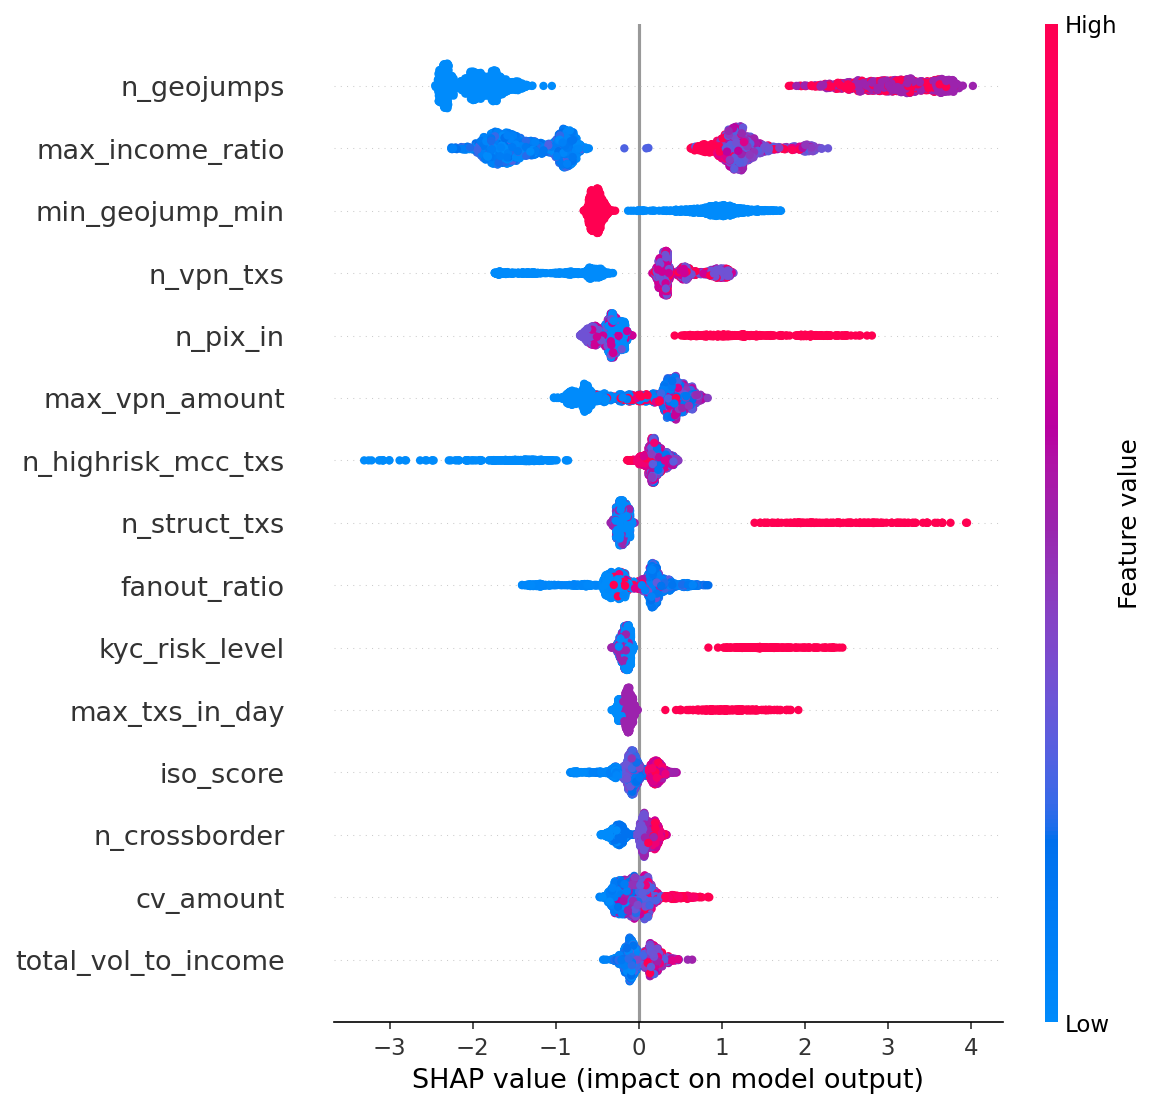

In [28]:
# Exibir SHAP summary plot já gerado
from IPython.display import Image
Image(BASE + 'shap_summary.png', width=700)

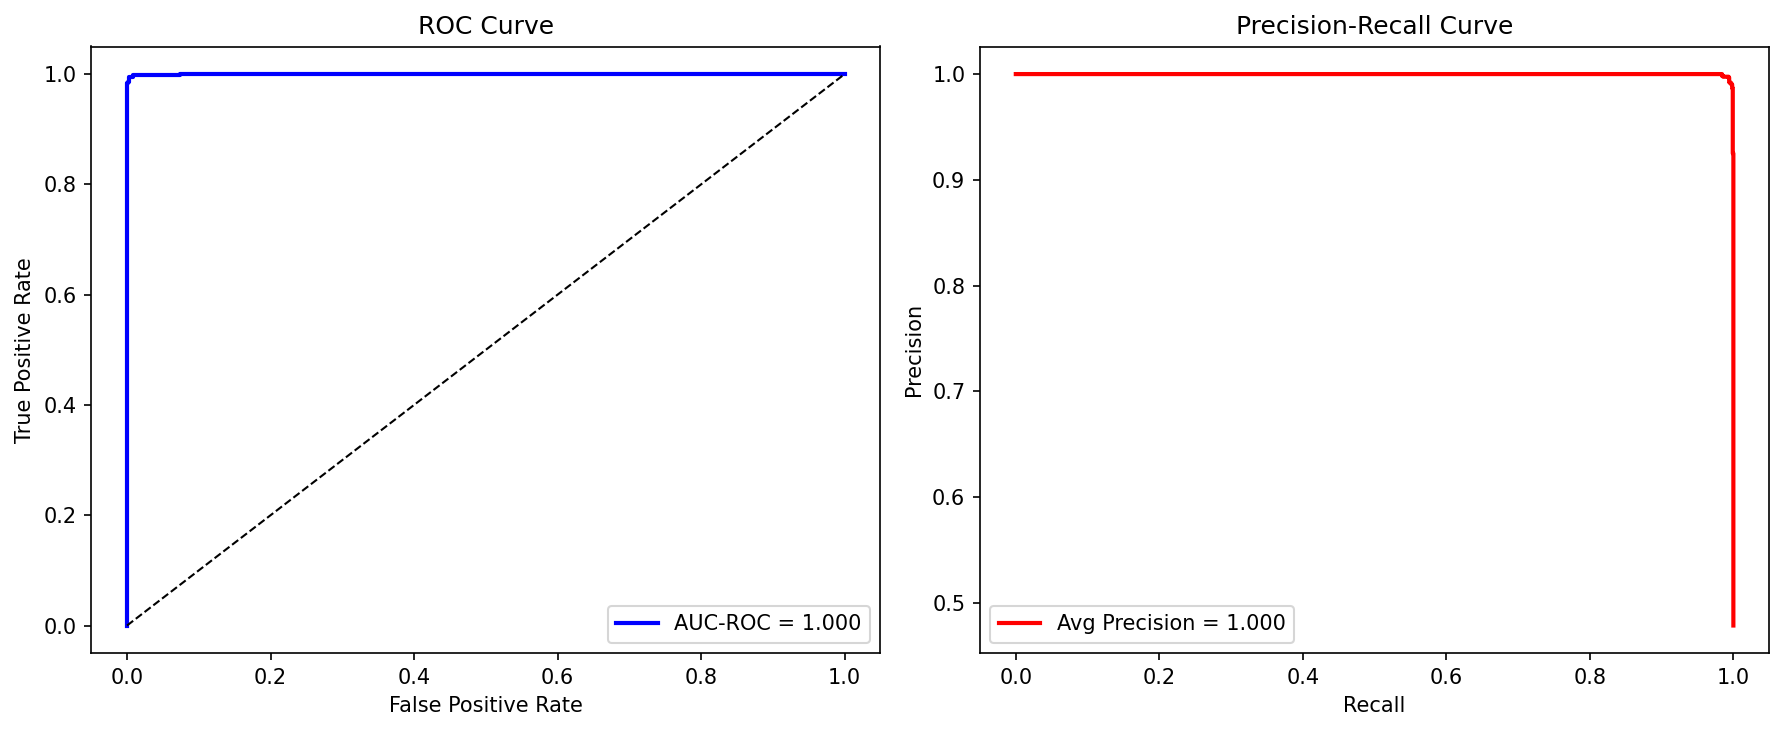

In [29]:
# Exibir curvas ROC e PR
Image(BASE + 'roc_pr_curves.png', width=700)

## 6. Multi-agente LLM — Outputs (Tarefa 4)
5 agentes: Dados → Detecção → Investigação → SAR → Compliance

In [30]:
import glob

# Listar casos processados
case_files = sorted(glob.glob(BASE + 'aml_case_*.json'))
print(f"Casos processados: {len(case_files)}")
for f in case_files:
    with open(f) as fp:
        d = json.load(fp)
    det = d.get('deteccao', {})
    comp = d.get('compliance', {})
    sar = d.get('sar', {})
    print(f"  {d['customer_id']:10s} | Detecção: {det.get('decisao','?'):12s} (score {det.get('score_deteccao','?')}) "
          f"| Compliance: {comp.get('decisao_final','?'):25s} (score {comp.get('score_compliance','?')}) "
          f"| Certeza: {sar.get('grau_certeza','?')} | {d['total_segundos']}s")

Casos processados: 5
  C100091    | Detecção: INVESTIGAR   (score 85) | Compliance: APROVADO_COM_RESSALVAS    (score 85) | Certeza: ALTO | 115.5s
  C100932    | Detecção: INVESTIGAR   (score 95) | Compliance: APROVADO_COM_RESSALVAS    (score 85) | Certeza: ALTO | 92.2s
  C101048    | Detecção: INVESTIGAR   (score 95) | Compliance: APROVADO_COM_RESSALVAS    (score 85) | Certeza: ALTO | 56.0s
  C101208    | Detecção: INVESTIGAR   (score 85) | Compliance: APROVADO_COM_RESSALVAS    (score 80) | Certeza: ALTO | 49.4s
  C102221    | Detecção: INVESTIGAR   (score 85) | Compliance: APROVADO_COM_RESSALVAS    (score 85) | Certeza: ALTO | 143.5s


In [31]:
# Inspecionar output completo de um caso — alterar customer_id conforme necessário
CASO = 'C101208'

with open(BASE + f'aml_case_{CASO}.json') as f:
    case = json.load(f)

print(f"=== PIPELINE LOG — {CASO} ===")
for step in case['pipeline_log']:
    print(f"  [{step['agente']:15s}] {step['elapsed_s']}s | keys: {step['keys']}")

=== PIPELINE LOG — C101208 ===
  [DADOS          ] 2.4s | keys: ['customer_id', 'perfil_resumido', 'kyc_highlights', 'transacoes_highlights', 'dados_estruturados', 'nivel_dados']
  [DETECCAO       ] 2.2s | keys: ['decisao', 'score_deteccao', 'flags_acionadas', 'tipologias_identificadas', 'justificativa', 'urgencia', 'proximo_passo']
  [INVESTIGACAO   ] 4.6s | keys: ['tipologia_principal', 'tipologias_secundarias', 'narrativa_investigativa', 'linha_do_tempo', 'evidencias_fortes', 'evidencias_fracas', 'rede_suspeita', 'lacunas_investigativas', 'recomendacao_sar', 'fundamentacao_legal']
  [SAR            ] 15.4s | keys: ['sar_numero', 'data_emissao', 'classificacao', 'secao_1_identificacao', 'secao_2_resumo_executivo', 'secao_3_descricao_operacoes', 'secao_4_tipologia', 'secao_5_fundamentacao_legal', 'secao_6_evidencias', 'secao_7_medidas_tomadas', 'secao_8_conclusao', 'grau_certeza', 'prazo_comunicacao_coaf']
  [COMPLIANCE     ] 24.8s | keys: ['decisao_final', 'score_compliance', 'avalia

In [32]:
# Output do Agente DETECÇÃO
det = case['deteccao']
print(f"Decisão: {det.get('decisao')} | Score: {det.get('score_deteccao')} | Urgência: {det.get('urgencia')}")
print(f"\nJustificativa:\n{det.get('justificativa','')}")
print(f"\nTipologias: {det.get('tipologias_identificadas',[])}")
print(f"\nFlags acionadas:")
for flag in det.get('flags_acionadas', []):
    print(f"  [{flag.get('peso','?'):5s}] {flag.get('flag','?')}: {flag.get('evidencia','')}")

Decisão: INVESTIGAR | Score: 85 | Urgência: ALTA

Justificativa:
O perfil do cliente apresenta várias inconsistências e indícios de lavagem de dinheiro, incluindo uma renda anual incompatível com transações de alto valor, transações internacionais em curto período de tempo e um score de risco alto. Além disso, o cliente realizou transações em países como Portugal e Rússia, o que pode indicar uma tentativa de ocultar a origem dos fundos. Portanto, é necessário investigar mais a fundo para determinar se o cliente está envolvido em atividades ilícitas.

Tipologias: ['Income Ratio', 'Geo-jump', 'Transações Internacionais']

Flags acionadas:
  [ALTO ] Income Ratio: Renda anual de R$ 13.047,00 incompatível com transações de alto valor (ex: R$ 34.398,52)
  [ALTO ] Geo-jump: Transações em países como Portugal e Rússia em curto período de tempo
  [MEDIO] Transações Internacionais: 9 transações internacionais realizadas no período de 2025-07-03 a 2025-10-02
  [ALTO ] ML Score: Score de risco de 

In [33]:
# Output do Agente INVESTIGAÇÃO
inv = case['investigacao']
print(f"Tipologia principal: {inv.get('tipologia_principal','?')}")
print(f"Recomendação SAR: {inv.get('recomendacao_sar','?')}")
print(f"\nEvidências fortes:")
for e in inv.get('evidencias_fortes', []):
    print(f"  + {e}")
print(f"\nLinha do tempo:")
for ev in inv.get('linha_do_tempo', [])[:5]:
    print(f"  [{ev.get('relevancia','?'):5s}] {ev.get('data','?')} — {ev.get('evento','')}")

Tipologia principal: Lavagem de Dinheiro por meio de Transações Internacionais
Recomendação SAR: EMITIR

Evidências fortes:
  + Transações de alto valor com países de alto risco
  + Uso de VPN para ocultar a origem das transações
  + Inconsistências na declaração de renda e ocupação
  + Padrão de comportamento recorrente e sistemático

Linha do tempo:
  [BAIXA] 2025-07-03 — Transação de R$ 3.443,62 via PIX
  [MÉDIA] 2025-07-09 — Transação de R$ 4.116,51 via Cartão
  [BAIXA] 2025-07-21 — Transação de R$ 830,85 via Cartão
  [ALTA ] 2025-07-22 — Transação de R$ 1.241,06 via PIX, com VPN
  [ALTA ] 2025-07-24 — Transação de R$ 34.398,52 via PIX


In [34]:
# Output do Agente SAR
sar = case['sar']
print(f"SAR Nº: {sar.get('sar_numero','?')}")
print(f"Classificação: {sar.get('classificacao','?')}")
print(f"Grau de certeza: {sar.get('grau_certeza','?')}")
print(f"Prazo COAF: {sar.get('prazo_comunicacao_coaf','?')}")
print(f"\nResumo Executivo:\n{sar.get('secao_2_resumo_executivo','')}")

tipo = sar.get('secao_4_tipologia', {})
print(f"\nTipologia: {tipo.get('tipologia_principal','?')}")
print(f"Fase LD: {tipo.get('fase_ld','?')}")
print(f"Base FATF: {tipo.get('base_fatf','?')}")

SAR Nº: SAR-2026-05-AUTO
Classificação: CONFIDENCIAL
Grau de certeza: ALTO
Prazo COAF: 24h

Resumo Executivo:
O cliente C101208, um chef brasileiro, apresenta um perfil de risco baixo, mas seu histórico de transações revela padrões suspeitos. Em um período de aproximadamente 3 meses, o cliente realizou 34 transações, totalizando R$ 150.178,09, com valores que ultrapassam sua renda anual declarada. Além disso, o cliente realizou transações internacionais com países como Portugal e Rússia, utilizando diferentes canais de pagamento, incluindo PIX, Cartão e Transferência Bancária.

Tipologia: Lavagem de Dinheiro por meio de Transações Internacionais
Fase LD: Layering
Base FATF: FATF Recomendação 1


In [35]:
# Output do Agente COMPLIANCE
comp = case['compliance']
print(f"Decisão final: {comp.get('decisao_final','?')}")
print(f"Score compliance: {comp.get('score_compliance','?')}/100")
print(f"Avaliação evidências: {comp.get('avaliacao_evidencias','?')}")
print(f"Risco NÃO reportar: {comp.get('risco_nao_reportar','?')}")
print(f"Prazo de ação: {comp.get('prazo_acao','?')}")
print(f"\nChecklist COAF: {comp.get('checklist_coaf',{})}")
print(f"\nRessalvas:")
for r in comp.get('ressalvas', []):
    print(f"  ! {r}")
print(f"\nInstruções finais:\n{comp.get('instrucoes_finais','')}")

Decisão final: APROVADO_COM_RESSALVAS
Score compliance: 80/100
Avaliação evidências: SUFICIENTE
Risco NÃO reportar: ALTO
Prazo de ação: 24h

Checklist COAF: {'identificacao_completa': True, 'descricao_operacoes': True, 'tipologia_identificada': True, 'fundamentacao_legal': True, 'medidas_tomadas': True, 'prazo_comunicacao': True}

Ressalvas:
  ! Ajustar a seção 6 do SAR para incluir mais detalhes sobre as evidências objetivas
  ! Incluir mais informações sobre a rede de relacionamentos do cliente
  ! Verificar se há mais evidências de lavagem de dinheiro antes de submeter o SAR

Instruções finais:
A equipe deve ajustar o SAR de acordo com as ressalvas e incluir mais detalhes sobre as evidências objetivas e a rede de relacionamentos do cliente. Além disso, é importante verificar se há mais evidências de lavagem de dinheiro antes de submeter o SAR. O prazo para submissão é de 24 horas.


In [36]:
# Comparar todos os casos — tabela resumo
rows = []
for f in sorted(glob.glob(BASE + 'aml_case_*.json')):
    with open(f) as fp:
        d = json.load(fp)
    rows.append({
        'customer_id': d['customer_id'],
        'decisao_deteccao': d['deteccao'].get('decisao','?'),
        'score_deteccao': d['deteccao'].get('score_deteccao','?'),
        'tipologia_principal': d['investigacao'].get('tipologia_principal','?'),
        'sar_numero': d['sar'].get('sar_numero','?'),
        'grau_certeza': d['sar'].get('grau_certeza','?'),
        'prazo_coaf': d['sar'].get('prazo_comunicacao_coaf','?'),
        'decisao_compliance': d['compliance'].get('decisao_final','?'),
        'score_compliance': d['compliance'].get('score_compliance','?'),
        'total_s': d['total_segundos'],
    })

pd.DataFrame(rows)

,customer_id,decisao_deteccao,score_deteccao,tipologia_principal,sar_numero,grau_certeza,prazo_coaf,decisao_compliance,score_compliance,total_s
0,C100091,INVESTIGAR,85,Lavagem de Dinheiro,SAR-2026-05-AUTO,ALTO,24h,APROVADO_COM_RESSALVAS,85,115.50
1,C100932,INVESTIGAR,95,Lavagem de Dinheiro por meio de Transações Financeiras,SAR-2026-05-AUTO,ALTO,24h,APROVADO_COM_RESSALVAS,85,92.20
2,C101048,INVESTIGAR,95,Lavagem de Dinheiro - Tipologia 1: Introdução de Ativos ...,SAR-2026-05-AUTO,ALTO,24h,APROVADO_COM_RESSALVAS,85,56.00
3,C101208,INVESTIGAR,85,Lavagem de Dinheiro por meio de Transações Internacionais,SAR-2026-05-AUTO,ALTO,24h,APROVADO_COM_RESSALVAS,80,49.40
4,C102221,INVESTIGAR,85,Lavagem de Dinheiro - Structuring/Smurfing,SAR-2026-05-AUTO,ALTO,24h,APROVADO_COM_RESSALVAS,85,143.50


---
## Query Livre
Use `q("sua query SQL aqui")` para explorar qualquer aspecto do banco.

In [37]:
# Escreva sua query aqui
q("""
SELECT * FROM transactions LIMIT 5
""")

,transaction_id,timestamp,transaction_type,sender_id,sender_entity_type,receiver_id,receiver_entity_type,amount_brl,amount_orig,currency,fx_to_brl,status,channel,capture_method,payment_method,installments,issuing_or_acquiring,pix,pix_flow,card_brand,card_present,auth_3ds,eci,mcc,geo_country,geolocation_lat,geolocation_lon,ip_country,ip_anomaly,ip_proxy_vpn_tor,device_fingerprint,ip_address,device_rooted,sender_country,receiver_country,country_risk_geo,country_risk_ip,country_risk_sender,country_risk_receiver,cross_border,sanctions_screening_hit
0,T9HIMVHJ8TMK7,2025-09-29T01:19:37,PIX,C100602,customer,M200223,merchant,3478.73,3478.73,BRL,1.0,Confirmed,App,CopyPaste,n/a,1.0,n/a,Yes,cash_out,n/a,n/a,n/a,n/a,6051.0,BR,-11.743364,-54.286939,DE,No,None,poq50ptmz8g3pgoh,193.59.218.134,No,BR,BR,Low,Low,Low,Low,No,No
1,TRY1GG0393ZEQ,2025-09-07T00:14:11,PIX,C101190,customer,M200471,merchant,3356.15,3356.15,BRL,1.0,Confirmed,App,Pix Key,n/a,1.0,n/a,Yes,cash_out,n/a,n/a,n/a,n/a,5945.0,BR,-0.031356,-62.010354,BR,No,None,ve5ar34n3q5arhcn,118.247.245.154,No,BR,BR,Low,Low,Low,Low,No,No
2,TYVX10N3OXT1H,2025-07-01T22:36:33,PIX,C101811,customer,C101070,customer,1595.14,1595.14,BRL,1.0,Confirmed,App,CopyPaste,n/a,1.0,n/a,Yes,cash_out,n/a,n/a,n/a,n/a,4111.0,BR,-17.208767,-66.365148,BR,No,None,bnv7ad7zrmn7cgfh,169.185.50.15,No,BR,BR,Low,Low,Low,Low,No,No
3,TEXB9LV0C1BOI,2025-07-28T09:01:56,PIX,C100023,customer,C101820,customer,1074.71,1074.71,BRL,1.0,Confirmed,App,Pix Key,n/a,1.0,n/a,Yes,cash_out,n/a,n/a,n/a,n/a,5945.0,BR,-8.096121,-57.440608,BR,No,VPN,h96qnwm3yju8wdd9,150.97.162.214,No,BR,BR,Low,Low,Low,Low,No,No
4,T9HZ6Z1DWO12V,2025-07-27T00:36:40,PIX,M200612,merchant,C101267,customer,6821.96,6821.96,BRL,1.0,Pending,API,QR Static,n/a,1.0,n/a,Yes,cash_in,n/a,n/a,n/a,n/a,6211.0,BR,-16.441953,-54.044138,BR,No,None,elmh8kqwykznkcfz,23.56.92.120,No,BR,BR,Low,Low,Low,Low,No,No
